# Exhaustive Inference Evaluation for Incremental Fine-Tuning Analysis

This notebook provides a comprehensive inference pipeline to evaluate ProPicker checkpoints from the incremental fine-tuning experiment (EXP3). It extends previous evaluation approaches with:

1. **Multi-checkpoint evaluation**: Systematic inference on all checkpoints from increments [1, 2, 4, 8, 12, 16, 20]
2. **Multi-instance prompt evaluation**: Comparison between single-instance and 10-instance averaged prompts
3. **Comprehensive metrics**: Precision, Recall, F1, and distance-based analysis
4. **Visualization**: Performance curves and comparative analysis

## Multi-Instance Prompt Strategy

TomoTwin embeds 37×37×37 subtomograms into 32-dimensional vectors. For a **single-instance prompt**, we use one representative particle. For a **multi-instance prompt (N=10)**, we:
1. Extract N diverse particle subtomograms
2. Pass each through TomoTwin individually
3. Average the N embeddings to create a more robust prompt representation

This approach should reduce sensitivity to individual particle variations and improve generalization.

In [1]:
import sys
from pathlib import Path

# Add project root and experiments to path
PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

# Import paths (file system locations)
from paths import (
    UMU_SYNTH_DIR,
    UMU_SYNTH_TOMOS_DIR,
    UMU_SYNTH_CSV,
    TOMOTWIN_MODEL_FILE,
    PROPICKER_TOOLS_DIR,
    PROPICKER_MODEL_FILE,
    EXP3_RESULTS_DIR,
    EXP3_FINETUNING_DIR,
    EXP3_INFERENCE_DIR,
    EXP3_DATA_DIR,
    EXP3_COORDS_DIR,
    EXP3_CHECKPOINTS_DIR,
)

# Import config (experiment parameters and utilities)
from experiments.config import (
    setup_propicker_paths,
    THYROGLOBULIN_NAME,
    THYROGLOBULIN_LABEL,
    PROMPT_SIZE,
    PROMPT_HALF,
    THYROGLOBULIN_DIAMETER,
    LABEL_DIAMETER,
    EXP3_TRAIN_POOL,
    EXP3_VAL_TOMOS,
    EXP3_INCREMENTS,
)

# Setup ProPicker imports
PROPICKER_DIR = setup_propicker_paths()

# Aliases
PARTICLE_TYPE = THYROGLOBULIN_NAME
EXP_RESULTS_DIR = EXP3_RESULTS_DIR
COORDS_DIR = EXP3_COORDS_DIR

import subprocess
import json
import pandas as pd
import numpy as np
import torch
from matplotlib import pyplot as plt
from scipy import ndimage
from scipy.spatial.distance import cdist

from inference.tomotwin import get_tomotwin_prompt_embeds_dict, pass_subtomos_through_tomotwin
from utils.mrctools import load_mrc_data

import warnings
warnings.filterwarnings("ignore")

print(f"ProPicker tools: {PROPICKER_DIR}")
print(f"UMU Synth data: {UMU_SYNTH_DIR}")
print(f"TomoTwin model: {TOMOTWIN_MODEL_FILE}")
print(f"Results dir: {EXP_RESULTS_DIR}")
print(f"Checkpoints dir: {EXP3_CHECKPOINTS_DIR}")
print(f"\nExperiment parameters:")
print(f"  Validation tomograms: {EXP3_VAL_TOMOS}")
print(f"  Training increments: {EXP3_INCREMENTS}")
print(f"  Prompt size: {PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE}")

ProPicker tools: /home/carloshg/Dev/cryoet-particle-picking/tools/ProPicker/propicker
UMU Synth data: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth
TomoTwin model: /home/carloshg/Dev/cryoet-particle-picking/models/tomotwin.pth
Results dir: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits
Checkpoints dir: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/checkpoints

Experiment parameters:
  Validation tomograms: ['tomo_rec_5_snr1.66', 'tomo_rec_6_snr1.17', 'tomo_rec_7_snr1.13', 'tomo_rec_8_snr0.57', 'tomo_rec_9_snr1.28']
  Training increments: [1, 2, 4, 8, 12, 16, 20]
  Prompt size: 37×37×37


## Step 1: Check Available Checkpoints

Verify which checkpoints from the incremental training are available for evaluation.

In [2]:
print("=" * 70)
print("AVAILABLE CHECKPOINTS FOR EVALUATION")
print("=" * 70)

available_checkpoints = {}

for increment in EXP3_INCREMENTS:
    ckpt_path = EXP3_CHECKPOINTS_DIR / f"increment_{increment}" / "best_model.ckpt"
    if ckpt_path.exists():
        available_checkpoints[increment] = ckpt_path
        print(f"  ✅ Increment {increment:2d}: {ckpt_path.name}")
    else:
        print(f"  ❌ Increment {increment:2d}: NOT FOUND")

print(f"\n📊 Available: {len(available_checkpoints)}/{len(EXP3_INCREMENTS)} checkpoints")

if len(available_checkpoints) == 0:
    print("\n⚠️  No checkpoints found. Run the fine-tuning script first:")
    print(f"    cd {PROJECT_ROOT}/tools/ProPicker")
    print(f"    python ../../experiments/exp3_ppicker_limits/scripts/umusynth_fine_tuning.py")

AVAILABLE CHECKPOINTS FOR EVALUATION
  ✅ Increment  1: best_model.ckpt
  ✅ Increment  2: best_model.ckpt
  ✅ Increment  4: best_model.ckpt
  ✅ Increment  8: best_model.ckpt
  ✅ Increment 12: best_model.ckpt
  ✅ Increment 16: best_model.ckpt
  ✅ Increment 20: best_model.ckpt

📊 Available: 7/7 checkpoints


## Step 2: Load Ground Truth Coordinates

Load ground truth particle coordinates for the validation set.

In [3]:
print("=" * 70)
print("LOADING GROUND TRUTH COORDINATES")
print("=" * 70)

gt_coords_dict = {}

for tomo_name in EXP3_VAL_TOMOS:
    coord_file = COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    if coord_file.exists():
        df = pd.read_csv(coord_file)
        gt_coords_dict[tomo_name] = df[['X', 'Y', 'Z']].values
        print(f"  ✅ {tomo_name}: {len(df)} particles")
    else:
        print(f"  ❌ {tomo_name}: coords file not found")

total_particles = sum(len(coords) for coords in gt_coords_dict.values())
print(f"\n📊 Total ground truth particles: {total_particles}")

LOADING GROUND TRUTH COORDINATES
  ✅ tomo_rec_5_snr1.66: 127 particles
  ✅ tomo_rec_6_snr1.17: 120 particles
  ✅ tomo_rec_7_snr1.13: 133 particles
  ✅ tomo_rec_8_snr0.57: 115 particles
  ✅ tomo_rec_9_snr1.28: 127 particles

📊 Total ground truth particles: 622


## Step 3: Extract Subtomograms for Multi-Instance Prompt

Extract multiple particle subtomograms to create both single-instance and multi-instance (10) prompts.

In [4]:
def extract_subtomograms(tomo, coords, patch_size=37):
    """
    Extract subtomograms of given size around each coordinate.
    
    Args:
        tomo: 3D tensor (Z, Y, X)
        coords: Array of (X, Y, Z) coordinates
        patch_size: Size of subtomogram (default 37 for TomoTwin)
        
    Returns:
        List of valid subtomograms, list of valid coordinates
    """
    half = patch_size // 2
    subtomos = []
    valid_coords = []
    
    for coord in coords:
        x, y, z = coord.astype(int)
        
        # Extract patch centered at (x, y, z)
        # Note: tomo is (Z, Y, X) but coords are (X, Y, Z)
        z_start, z_end = z - half, z + half + 1
        y_start, y_end = y - half, y + half + 1
        x_start, x_end = x - half, x + half + 1
        
        # Check bounds
        if (z_start < 0 or z_end > tomo.shape[0] or
            y_start < 0 or y_end > tomo.shape[1] or
            x_start < 0 or x_end > tomo.shape[2]):
            continue
            
        subtomo = tomo[z_start:z_end, y_start:y_end, x_start:x_end]
        
        if subtomo.shape == (patch_size, patch_size, patch_size):
            subtomos.append(subtomo)
            valid_coords.append(coord)
            
    return subtomos, np.array(valid_coords) if valid_coords else np.array([]).reshape(0, 3)

# Extract subtomograms from TRAINING tomograms (not validation)
# to avoid data leakage
print("=" * 70)
print("EXTRACTING SUBTOMOGRAMS FOR PROMPT GENERATION")
print("=" * 70)

all_subtomos = []
all_coords = []

# Use first few training tomograms to get diverse samples
source_tomos = EXP3_TRAIN_POOL[:5]  # Use 5 training tomos

for tomo_name in source_tomos:
    # Load tomogram
    tomo_path = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
    if not tomo_path.exists():
        continue
    
    tomo = load_mrc_data(str(tomo_path)).float()
    
    # Load coordinates
    coord_file = COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
    if not coord_file.exists():
        continue
    
    coords_df = pd.read_csv(coord_file)
    coords = coords_df[['X', 'Y', 'Z']].values
    
    # Extract subtomograms
    subtomos, valid_coords = extract_subtomograms(tomo, coords, patch_size=PROMPT_SIZE)
    
    all_subtomos.extend(subtomos)
    all_coords.extend(valid_coords)
    
    print(f"  {tomo_name}: extracted {len(subtomos)} subtomograms")
    del tomo

print(f"\n📊 Total extracted subtomograms: {len(all_subtomos)}")

EXTRACTING SUBTOMOGRAMS FOR PROMPT GENERATION
  tomo_rec_0_snr1.63: extracted 133 subtomograms
  tomo_rec_1_snr1.46: extracted 109 subtomograms
  tomo_rec_2_snr1.07: extracted 112 subtomograms
  tomo_rec_3_snr0.63: extracted 108 subtomograms
  tomo_rec_4_snr1.85: extracted 114 subtomograms

📊 Total extracted subtomograms: 576


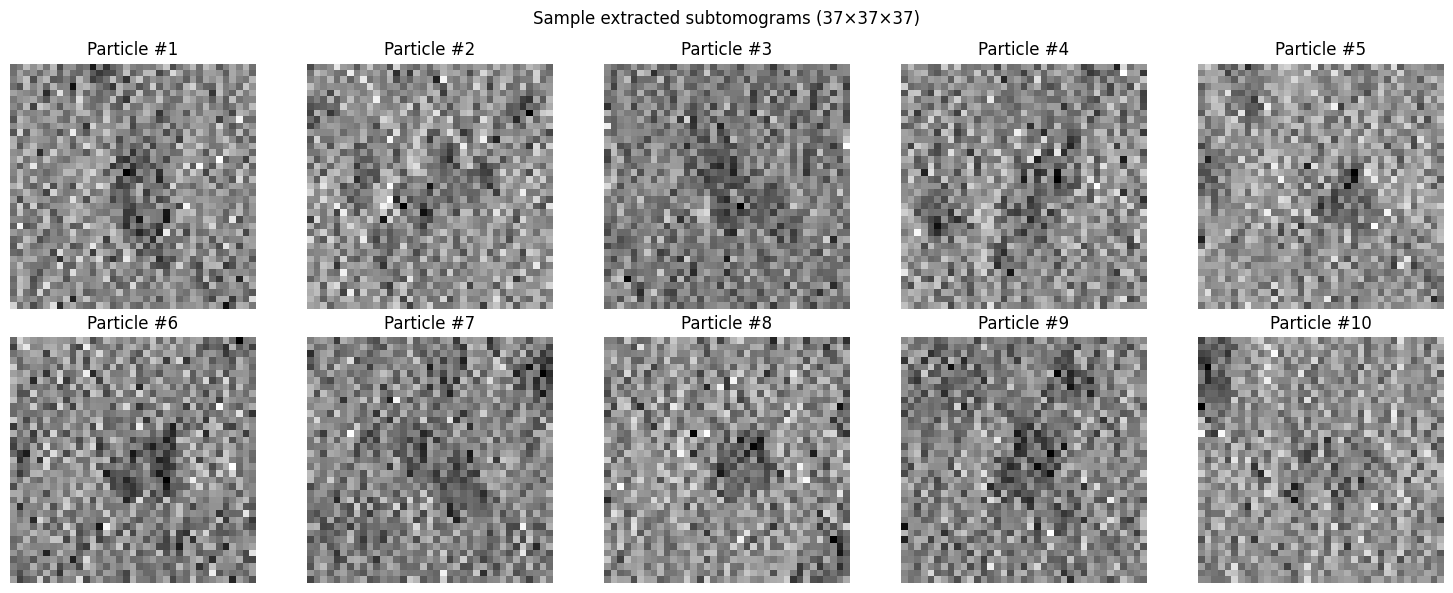

In [5]:
# Visualize some extracted subtomograms
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    if i < len(all_subtomos):
        subtomo = all_subtomos[i]
        if isinstance(subtomo, torch.Tensor):
            subtomo = subtomo.numpy()
        central_slice = subtomo[PROMPT_SIZE // 2]
        ax.imshow(central_slice, cmap='gray')
        ax.set_title(f"Particle #{i+1}")
    ax.axis('off')

plt.suptitle(f"Sample extracted subtomograms ({PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE})")
plt.tight_layout()
plt.show()

## Step 4: Generate Single and Multi-Instance Prompts

Create two types of prompt embeddings:
1. **Single-instance prompt**: One representative particle (same as original fine-tuning)
2. **Multi-instance prompt (N=10)**: Average of 10 diverse particle embeddings

In [6]:
def select_diverse_samples(subtomos, n_samples=10, method='variance'):
    """
    Select N diverse subtomograms from a larger set.
    
    Args:
        subtomos: List of subtomograms
        n_samples: Number of samples to select
        method: Selection method ('variance', 'random', 'uniform')
    
    Returns:
        List of selected subtomogram indices
    """
    if len(subtomos) <= n_samples:
        return list(range(len(subtomos)))
    
    if method == 'random':
        return list(np.random.choice(len(subtomos), n_samples, replace=False))
    
    elif method == 'uniform':
        # Uniformly spaced indices
        return list(np.linspace(0, len(subtomos)-1, n_samples, dtype=int))
    
    elif method == 'variance':
        # Select based on variance ranking (diverse variance levels)
        variances = []
        for s in subtomos:
            if isinstance(s, torch.Tensor):
                s = s.numpy()
            variances.append(np.var(s))
        
        # Sort by variance and take uniformly from the ranked list
        sorted_indices = np.argsort(variances)
        selected = sorted_indices[np.linspace(0, len(sorted_indices)-1, n_samples, dtype=int)]
        return list(selected)
    
    return list(range(n_samples))

# Number of instances for multi-prompt
N_INSTANCES = 10

print("=" * 70)
print("GENERATING PROMPT EMBEDDINGS")
print("=" * 70)

# Convert subtomograms to tensor
subtomos_tensor = torch.stack([torch.tensor(s) if not isinstance(s, torch.Tensor) else s 
                               for s in all_subtomos])

print(f"\nSubtomograms tensor shape: {subtomos_tensor.shape}")

# Select diverse samples for multi-instance prompt
selected_indices = select_diverse_samples(all_subtomos, n_samples=N_INSTANCES, method='variance')
print(f"\nSelected indices for {N_INSTANCES}-instance prompt: {selected_indices}")

# Generate embeddings for all selected subtomograms
print(f"\nGenerating embeddings using TomoTwin...")
selected_subtomos = subtomos_tensor[selected_indices]

# Pass through TomoTwin
embeddings = pass_subtomos_through_tomotwin(
    subtomos=selected_subtomos,
    tomotwin_model_file=str(TOMOTWIN_MODEL_FILE),
    batch_size=N_INSTANCES,
    device="cuda:0" if torch.cuda.is_available() else "cpu"
)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Embedding dimension: {embeddings.shape[1]}")

GENERATING PROMPT EMBEDDINGS

Subtomograms tensor shape: torch.Size([576, 37, 37, 37])

Selected indices for 10-instance prompt: [np.int64(530), np.int64(553), np.int64(50), np.int64(40), np.int64(158), np.int64(187), np.int64(322), np.int64(243), np.int64(378), np.int64(404)]

Generating embeddings using TomoTwin...


Passing subtomos through TomoTwin: 100%|█████████████████████| 1/1 [00:00<00:00, 12.24it/s]

Embeddings shape: torch.Size([10, 32])
Embedding dimension: 32


In [7]:
# Create single-instance prompt (first selected sample)
single_prompt_embedding = embeddings[0]

# Create multi-instance prompt (average of N embeddings)
multi_prompt_embedding = embeddings.mean(dim=0)

print("=" * 70)
print("PROMPT EMBEDDINGS COMPARISON")
print("=" * 70)

print(f"\n📌 Single-instance prompt:")
print(f"   Shape: {single_prompt_embedding.shape}")
print(f"   Norm: {single_prompt_embedding.norm():.4f}")
print(f"   Mean: {single_prompt_embedding.mean():.4f}")
print(f"   Std: {single_prompt_embedding.std():.4f}")

print(f"\n📌 Multi-instance prompt (N={N_INSTANCES}):")
print(f"   Shape: {multi_prompt_embedding.shape}")
print(f"   Norm: {multi_prompt_embedding.norm():.4f}")
print(f"   Mean: {multi_prompt_embedding.mean():.4f}")
print(f"   Std: {multi_prompt_embedding.std():.4f}")

# Cosine similarity between single and multi
cos_sim = torch.nn.functional.cosine_similarity(
    single_prompt_embedding.unsqueeze(0), 
    multi_prompt_embedding.unsqueeze(0)
).item()
print(f"\n📊 Cosine similarity (single vs multi): {cos_sim:.4f}")

# Variance of individual embeddings
embedding_variances = embeddings.var(dim=0).mean().item()
print(f"📊 Mean variance across embedding dimensions: {embedding_variances:.6f}")

PROMPT EMBEDDINGS COMPARISON

📌 Single-instance prompt:
   Shape: torch.Size([32])
   Norm: 1.0000
   Mean: 0.0042
   Std: 0.1796

📌 Multi-instance prompt (N=10):
   Shape: torch.Size([32])
   Norm: 0.8302
   Mean: 0.0012
   Std: 0.1491

📊 Cosine similarity (single vs multi): 0.9629
📊 Mean variance across embedding dimensions: 0.010789


In [8]:
# Save prompt embeddings to files
PROMPTS_DIR = EXP_RESULTS_DIR / "prompts"
PROMPTS_DIR.mkdir(parents=True, exist_ok=True)

# Single-instance prompt
single_prompt_file = PROMPTS_DIR / "single_instance_prompt.json"
single_prompt_dict = {PARTICLE_TYPE: single_prompt_embedding.tolist()}
with open(single_prompt_file, 'w') as f:
    json.dump(single_prompt_dict, f, indent=4)
print(f"✅ Single-instance prompt saved to: {single_prompt_file}")

# Multi-instance prompt
multi_prompt_file = PROMPTS_DIR / f"multi_instance_prompt_n{N_INSTANCES}.json"
multi_prompt_dict = {PARTICLE_TYPE: multi_prompt_embedding.tolist()}
with open(multi_prompt_file, 'w') as f:
    json.dump(multi_prompt_dict, f, indent=4)
print(f"✅ Multi-instance prompt (N={N_INSTANCES}) saved to: {multi_prompt_file}")

# Also save all individual embeddings for analysis
all_embeddings_file = PROMPTS_DIR / f"all_embeddings_n{N_INSTANCES}.pt"
torch.save({
    'embeddings': embeddings,
    'indices': selected_indices,
    'single_prompt': single_prompt_embedding,
    'multi_prompt': multi_prompt_embedding,
}, all_embeddings_file)
print(f"✅ All embeddings saved to: {all_embeddings_file}")

✅ Single-instance prompt saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/prompts/single_instance_prompt.json
✅ Multi-instance prompt (N=10) saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/prompts/multi_instance_prompt_n10.json
✅ All embeddings saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/prompts/all_embeddings_n10.pt


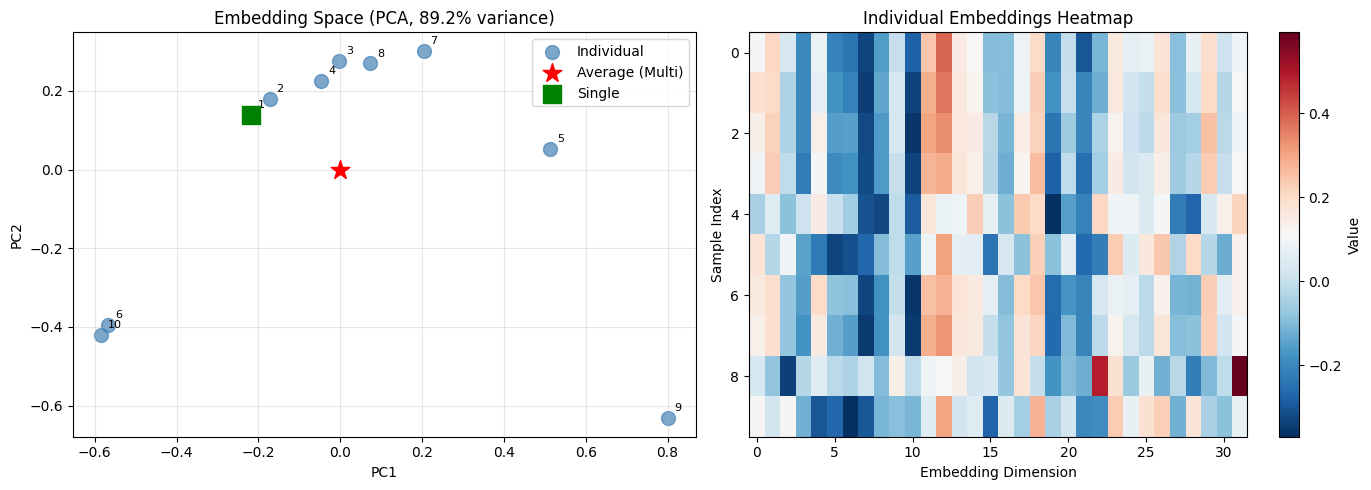


✅ Analysis plot saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/prompt_embeddings_analysis.png


In [9]:
# Visualize embedding space
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PCA of embeddings
pca = PCA(n_components=2)
embeddings_np = embeddings.detach().cpu().numpy()
embeddings_2d = pca.fit_transform(embeddings_np)
multi_2d = pca.transform(
    multi_prompt_embedding.detach().cpu().unsqueeze(0).numpy()
)

ax1 = axes[0]
ax1.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='steelblue', s=100, alpha=0.7, label='Individual')
ax1.scatter(multi_2d[:, 0], multi_2d[:, 1], c='red', s=200, marker='*', label='Average (Multi)', zorder=5)
ax1.scatter(embeddings_2d[0, 0], embeddings_2d[0, 1], c='green', s=150, marker='s', label='Single', zorder=5)

for i, (x, y) in enumerate(embeddings_2d):
    ax1.annotate(str(i+1), (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8)

ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_title(f'Embedding Space (PCA, {pca.explained_variance_ratio_.sum()*100:.1f}% variance)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Embedding dimension heatmap
ax2 = axes[1]
im = ax2.imshow(embeddings_np, aspect='auto', cmap='RdBu_r')
ax2.set_xlabel('Embedding Dimension')
ax2.set_ylabel('Sample Index')
ax2.set_title('Individual Embeddings Heatmap')
plt.colorbar(im, ax=ax2, label='Value')

plt.tight_layout()
plt.savefig(EXP_RESULTS_DIR / "prompt_embeddings_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Analysis plot saved to: {EXP_RESULTS_DIR / 'prompt_embeddings_analysis.png'}")

## Step 5: Evaluation Functions

Define functions to evaluate predictions against ground truth.

In [10]:
def evaluate_predictions(pred_coords, gt_coords, distance_thresh=18.5):
    """
    Evaluate predicted coordinates against ground truth.
    
    Args:
        pred_coords: Predicted coordinates (N, 3)
        gt_coords: Ground truth coordinates (M, 3)
        distance_thresh: Maximum distance for a match (default: PROMPT_SIZE/2)
    
    Returns:
        Dictionary with evaluation metrics
    """
    n_gt = len(gt_coords)
    n_pred = len(pred_coords)
    
    matched_gt = set()
    matched_pred = set()
    
    if n_pred > 0 and n_gt > 0:
        distances = cdist(pred_coords, gt_coords)
        
        # Greedy matching
        for i in range(len(pred_coords)):
            min_dist_idx = np.argmin(distances[i])
            if distances[i, min_dist_idx] < distance_thresh and min_dist_idx not in matched_gt:
                matched_gt.add(min_dist_idx)
                matched_pred.add(i)
    
    tp = len(matched_gt)
    fp = n_pred - tp
    fn = n_gt - tp
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    return {
        'n_gt': n_gt,
        'n_pred': n_pred,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'precision': precision,
        'recall': recall,
        'f1': f1,
    }


def load_predicted_coords(coords_file):
    """
    Load predicted coordinates from a .coords file.
    """
    if not coords_file.exists():
        return np.array([]).reshape(0, 3)
    
    df = pd.read_csv(coords_file, sep='\t', header=None, names=['X', 'Y', 'Z'])
    return df[['X', 'Y', 'Z']].values


def extract_coords_from_locmap(locmap_file, threshold=0.5):
    """
    Extract particle coordinates from a localization map.
    """
    locmap_data = torch.load(locmap_file, weights_only=False)
    
    if isinstance(locmap_data, dict):
        pred_locmap = list(locmap_data.values())[0]
        if hasattr(pred_locmap, 'numpy'):
            pred_locmap = pred_locmap.numpy()
    elif hasattr(locmap_data, 'numpy'):
        pred_locmap = locmap_data.numpy()
    else:
        pred_locmap = locmap_data
    
    # Handle 4D (C, D, H, W) format
    if len(pred_locmap.shape) == 4:
        if pred_locmap.shape[0] > 1:
            pred_locmap = pred_locmap[1]  # Foreground channel
        else:
            pred_locmap = pred_locmap[0]
    
    # Binarization and clustering
    binary_locmap = pred_locmap > threshold
    labeled_array, num_features = ndimage.label(binary_locmap)
    
    if num_features > 0:
        centroids = ndimage.center_of_mass(binary_locmap, labeled_array, range(1, num_features + 1))
        pred_coords = np.array(centroids)[:, ::-1]  # Convert (Z, Y, X) to (X, Y, Z)
    else:
        pred_coords = np.array([]).reshape(0, 3)
    
    return pred_coords

print("✅ Evaluation functions defined")

✅ Evaluation functions defined


## Step 6: Evaluate Inference Results

Evaluate results for all increments and both prompt types (single and multi-prompt).

**New structure:**
```
results_{prompt_type}/
├── increment_1/
│   ├── PredictedLabels/Coords_All/
│   └── full_segmentation_output/
├── increment_2/
├── ...
└── increment_20/
```

In [11]:
def evaluate_all_results():
    """
    Evaluate inference results for all increments and prompt types.
    
    Returns:
        DataFrame with all evaluation results
    """
    all_results = []
    
    # Find all results directories
    results_dirs = [d for d in EXP3_CHECKPOINTS_DIR.iterdir() 
                    if d.is_dir() and d.name.startswith("results_")]
    
    if not results_dirs:
        print("❌ No inference results found. Run the inference script first.")
        return None
    
    print("=" * 70)
    print("EVALUATING ALL INFERENCE RESULTS")
    print("=" * 70)
    
    for results_dir in sorted(results_dirs):
        prompt_type = results_dir.name.replace("results_", "")
        print(f"\n📁 {results_dir.name}")
        
        # Find increment subdirectories
        increment_dirs = [d for d in results_dir.iterdir() 
                         if d.is_dir() and d.name.startswith("increment_")]
        
        if not increment_dirs:
            print(f"   ⚠️ No increment subdirectories found (old structure?)")
            continue
        
        for inc_dir in sorted(increment_dirs, key=lambda x: int(x.name.split("_")[1])):
            increment = int(inc_dir.name.split("_")[1])
            coords_dir = inc_dir / "PredictedLabels" / "Coords_All"
            
            if not coords_dir.exists():
                continue
            
            print(f"   📊 Increment {increment}:")
            
            for tomo_name in EXP3_VAL_TOMOS:
                gt_coords = gt_coords_dict.get(tomo_name)
                if gt_coords is None:
                    continue
                
                coords_file = coords_dir / f"{tomo_name}.coords"
                if not coords_file.exists():
                    continue
                
                pred_coords = load_predicted_coords(coords_file)
                metrics = evaluate_predictions(pred_coords, gt_coords, distance_thresh=PROMPT_SIZE/2)
                metrics['tomo'] = tomo_name
                metrics['increment'] = increment
                metrics['prompt_type'] = prompt_type
                all_results.append(metrics)
            
            if any(r['increment'] == increment and r['prompt_type'] == prompt_type for r in all_results):
                inc_results = [r for r in all_results if r['increment'] == increment and r['prompt_type'] == prompt_type]
                mean_f1 = np.mean([r['f1'] for r in inc_results])
                mean_p = np.mean([r['precision'] for r in inc_results])
                mean_r = np.mean([r['recall'] for r in inc_results])
                print(f"      → P={mean_p:.3f}, R={mean_r:.3f}, F1={mean_f1:.3f}")
    
    if len(all_results) > 0:
        results_df = pd.DataFrame(all_results)
        print(f"\n✅ Total evaluations: {len(results_df)}")
        return results_df
    else:
        print("❌ No results found")
        return None

# Run evaluation
results_df = evaluate_all_results()

EVALUATING ALL INFERENCE RESULTS

📁 results_multi_prompt_n10
   📊 Increment 1:
      → P=0.702, R=0.606, F1=0.647
   📊 Increment 2:
      → P=0.795, R=0.696, F1=0.717
   📊 Increment 4:
      → P=0.828, R=0.927, F1=0.875
   📊 Increment 8:
      → P=0.862, R=0.955, F1=0.906
   📊 Increment 12:
      → P=0.894, R=0.947, F1=0.919
   📊 Increment 16:
      → P=0.880, R=0.947, F1=0.911
   📊 Increment 20:
      → P=0.846, R=0.955, F1=0.894

📁 results_single_prompt
   📊 Increment 1:
      → P=0.671, R=0.740, F1=0.691
   📊 Increment 2:
      → P=0.722, R=0.772, F1=0.728
   📊 Increment 4:
      → P=0.683, R=0.970, F1=0.800
   📊 Increment 8:
      → P=0.770, R=0.978, F1=0.860
   📊 Increment 12:
      → P=0.773, R=0.982, F1=0.862
   📊 Increment 16:
      → P=0.815, R=0.983, F1=0.888
   📊 Increment 20:
      → P=0.758, R=0.982, F1=0.849

✅ Total evaluations: 70


In [12]:
# Summary by prompt type and increment
if results_df is not None and len(results_df) > 0:
    print("=" * 70)
    print("SUMMARY BY PROMPT TYPE AND INCREMENT")
    print("=" * 70)
    
    summary = results_df.groupby(['prompt_type', 'increment']).agg({
        'precision': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'f1': ['mean', 'std'],
        'tp': 'sum',
        'fp': 'sum',
        'fn': 'sum'
    }).round(3)
    
    print(summary.to_string())
    
    # Save results
    results_file = EXP_RESULTS_DIR / "inference_all_results.csv"
    results_df.to_csv(results_file, index=False)
    print(f"\n✅ Results saved to: {results_file}")
    
    summary_file = EXP_RESULTS_DIR / "inference_summary.csv"
    summary.to_csv(summary_file)
    print(f"✅ Summary saved to: {summary_file}")

SUMMARY BY PROMPT TYPE AND INCREMENT
                           precision        recall            f1          tp   fp   fn
                                mean    std   mean    std   mean    std  sum  sum  sum
prompt_type      increment                                                            
multi_prompt_n10 1             0.702  0.393  0.606  0.354  0.647  0.366  384   60  238
                 2             0.795  0.242  0.696  0.375  0.717  0.367  440   54  182
                 4             0.828  0.065  0.927  0.072  0.875  0.068  578  118   44
                 8             0.862  0.082  0.955  0.054  0.906  0.070  595   95   27
                 12            0.894  0.080  0.947  0.053  0.919  0.067  590   70   32
                 16            0.880  0.102  0.947  0.045  0.911  0.076  590   83   32
                 20            0.846  0.141  0.955  0.044  0.894  0.103  595  118   27
single_prompt    1             0.671  0.245  0.740  0.382  0.691  0.333  468  153  154
      

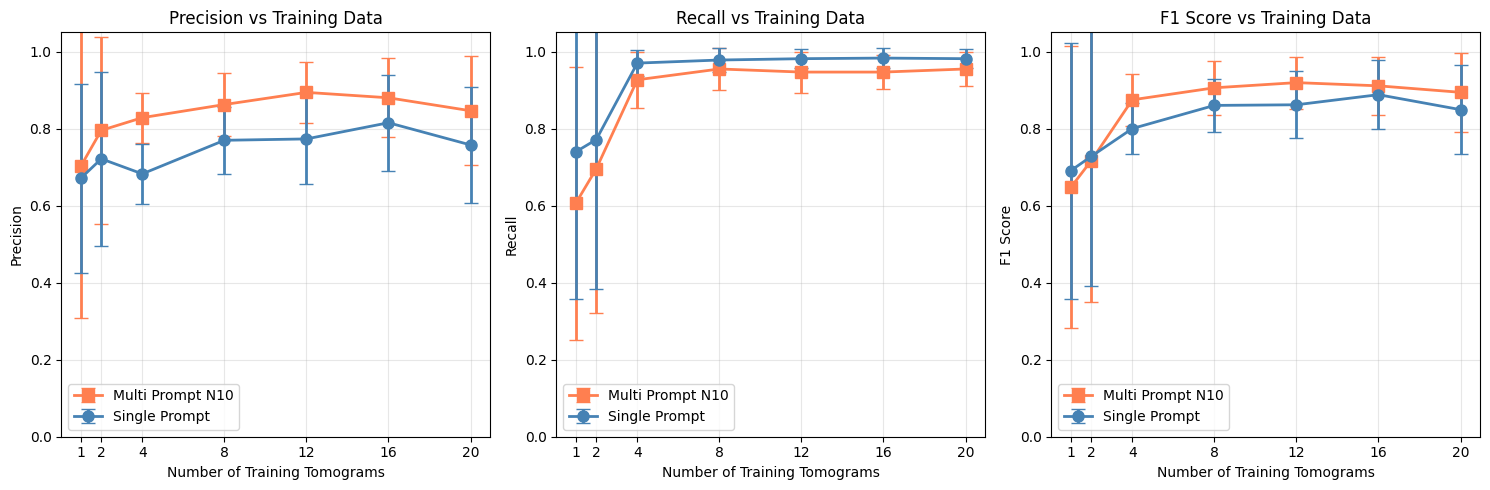


✅ Plot saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/performance_vs_training_data.png


In [13]:
# Performance vs Training Data (F1 Score)
if results_df is not None and len(results_df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    prompt_types = results_df['prompt_type'].unique()
    colors = {'single_prompt': 'steelblue', 'multi_prompt_n10': 'coral'}
    markers = {'single_prompt': 'o', 'multi_prompt_n10': 's'}
    
    for metric, ax, title in zip(['precision', 'recall', 'f1'], axes, ['Precision', 'Recall', 'F1 Score']):
        for pt in prompt_types:
            pt_data = results_df[results_df['prompt_type'] == pt]
            agg = pt_data.groupby('increment')[metric].agg(['mean', 'std']).reset_index()
            
            ax.errorbar(agg['increment'], agg['mean'], yerr=agg['std'],
                       marker=markers.get(pt, 'o'), capsize=5, linewidth=2, markersize=8,
                       color=colors.get(pt, 'gray'), label=pt.replace('_', ' ').title())
        
        ax.set_xlabel('Number of Training Tomograms')
        ax.set_ylabel(title)
        ax.set_title(f'{title} vs Training Data')
        ax.set_xticks(sorted(results_df['increment'].unique()))
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig(EXP_RESULTS_DIR / "performance_vs_training_data.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Plot saved to: {EXP_RESULTS_DIR / 'performance_vs_training_data.png'}")

In [14]:
# Comparison: Single vs Multi-Prompt per Increment
if results_df is not None and len(results_df) > 0 and len(results_df['prompt_type'].unique()) > 1:
    print("=" * 70)
    print("COMPARISON: SINGLE PROMPT vs MULTI-PROMPT")
    print("=" * 70)
    
    # Calculate improvement
    increments = sorted(results_df['increment'].unique())
    
    comparison_data = []
    for inc in increments:
        inc_data = results_df[results_df['increment'] == inc]
        
        for pt in inc_data['prompt_type'].unique():
            pt_inc = inc_data[inc_data['prompt_type'] == pt]
            comparison_data.append({
                'increment': inc,
                'prompt_type': pt,
                'mean_f1': pt_inc['f1'].mean(),
                'mean_precision': pt_inc['precision'].mean(),
                'mean_recall': pt_inc['recall'].mean(),
            })
    
    comp_df = pd.DataFrame(comparison_data)
    pivot_f1 = comp_df.pivot(index='increment', columns='prompt_type', values='mean_f1')
    
    print("\nMean F1 Score by Increment:")
    print(pivot_f1.round(3).to_string())
    
    if 'single_prompt' in pivot_f1.columns and 'multi_prompt_n10' in pivot_f1.columns:
        print("\n📊 F1 Improvement (Multi vs Single):")
        for inc in increments:
            if inc in pivot_f1.index:
                single = pivot_f1.loc[inc, 'single_prompt']
                multi = pivot_f1.loc[inc, 'multi_prompt_n10']
                diff = multi - single
                pct = (diff / single * 100) if single > 0 else 0
                print(f"   Increment {inc:2d}: {diff:+.3f} ({pct:+.1f}%)")
else:
    if results_df is not None:
        print("ℹ️ Only one prompt type available. Run inference with both prompts for comparison.")

COMPARISON: SINGLE PROMPT vs MULTI-PROMPT

Mean F1 Score by Increment:
prompt_type  multi_prompt_n10  single_prompt
increment                                   
1                       0.647          0.691
2                       0.717          0.728
4                       0.875          0.800
8                       0.906          0.860
12                      0.919          0.862
16                      0.911          0.888
20                      0.894          0.849

📊 F1 Improvement (Multi vs Single):
   Increment  1: -0.043 (-6.3%)
   Increment  2: -0.011 (-1.5%)
   Increment  4: +0.075 (+9.3%)
   Increment  8: +0.046 (+5.3%)
   Increment 12: +0.058 (+6.7%)
   Increment 16: +0.023 (+2.6%)
   Increment 20: +0.045 (+5.3%)


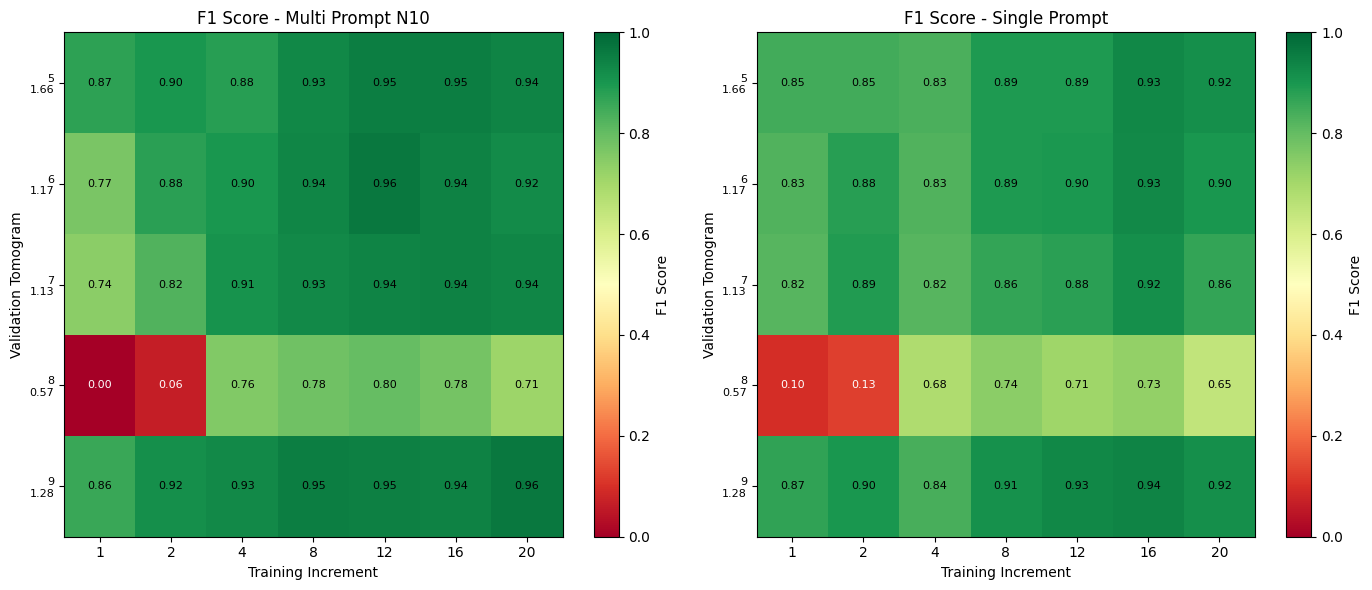


✅ Heatmap saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/f1_heatmap_by_increment.png


In [15]:
# Heatmap: F1 Score by Increment and Tomogram
if results_df is not None and len(results_df) > 0:
    prompt_types = results_df['prompt_type'].unique()
    n_prompts = len(prompt_types)
    
    fig, axes = plt.subplots(1, n_prompts, figsize=(7*n_prompts, 6))
    if n_prompts == 1:
        axes = [axes]
    
    for ax, pt in zip(axes, prompt_types):
        pt_data = results_df[results_df['prompt_type'] == pt]
        
        # Create pivot table
        pivot = pt_data.pivot_table(index='tomo', columns='increment', values='f1', aggfunc='mean')
        pivot = pivot.reindex(sorted(pivot.index, key=lambda x: x))
        
        im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
        
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([t.replace('tomo_rec_', '').replace('_snr', '\n') for t in pivot.index], fontsize=8)
        
        ax.set_xlabel('Training Increment')
        ax.set_ylabel('Validation Tomogram')
        ax.set_title(f'F1 Score - {pt.replace("_", " ").title()}')
        
        # Add text annotations
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                           color='white' if val < 0.5 else 'black', fontsize=8)
        
        plt.colorbar(im, ax=ax, label='F1 Score')
    
    plt.tight_layout()
    plt.savefig(EXP_RESULTS_DIR / "f1_heatmap_by_increment.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Heatmap saved to: {EXP_RESULTS_DIR / 'f1_heatmap_by_increment.png'}")

## Step 7: Running Inference with Different Prompts

The inference script automatically organizes results based on the prompt type used.

In [16]:
print("=" * 70)
print("INFERENCE COMMANDS")
print("=" * 70)

print(f"\n📁 Prompt files available:")
print(f"   Single-instance: {PROMPTS_DIR / 'single_instance_prompt.json'}")
print(f"   Multi-instance:  {PROMPTS_DIR / 'multi_instance_prompt_n10.json'}")

print(f"\n📋 To run inference for ALL increments:")
print(f"")
print(f"   # Navigate to ProPicker directory")
print(f"   cd {PROJECT_ROOT}/tools/ProPicker")
print(f"")
print(f"   # Run inference with single-instance prompt (default)")
print(f"   python ../../experiments/exp3_ppicker_limits/scripts/umusynth_inference.py")
print(f"")
print(f"   # Run inference with multi-instance prompt")
print(f"   python ../../experiments/exp3_ppicker_limits/scripts/umusynth_inference.py \\")
print(f"       --prompt-file {PROMPTS_DIR / 'multi_instance_prompt_n10.json'}")
print(f"")
print(f"📌 Results structure:")
print(f"   results_single_prompt/")
print(f"     ├── increment_1/")
print(f"     ├── increment_2/")
print(f"     ├── ...")
print(f"     └── increment_20/")
print(f"   results_multi_prompt_n10/")
print(f"     └── (same structure)")

INFERENCE COMMANDS

📁 Prompt files available:
   Single-instance: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/prompts/single_instance_prompt.json
   Multi-instance:  /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/prompts/multi_instance_prompt_n10.json

📋 To run inference for ALL increments:

   # Navigate to ProPicker directory
   cd /home/carloshg/Dev/cryoet-particle-picking/tools/ProPicker

   # Run inference with single-instance prompt (default)
   python ../../experiments/exp3_ppicker_limits/scripts/umusynth_inference.py

   # Run inference with multi-instance prompt
   python ../../experiments/exp3_ppicker_limits/scripts/umusynth_inference.py \
       --prompt-file /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits/prompts/multi_instance_prompt_n10.json

📌 Results structure:
   results_single_prompt/
     ├── increment_1/
     ├── increment_2/
     ├── ...
     └── increment_20/
   results_multi_prompt_n10/
   

## Step 8: Visualization of Inference Results

📊 Available prompt types: ['single_prompt', 'multi_prompt_n10']
📊 Using prompt type: single_prompt
📊 Increments to show: [1, 4, 8, 20]


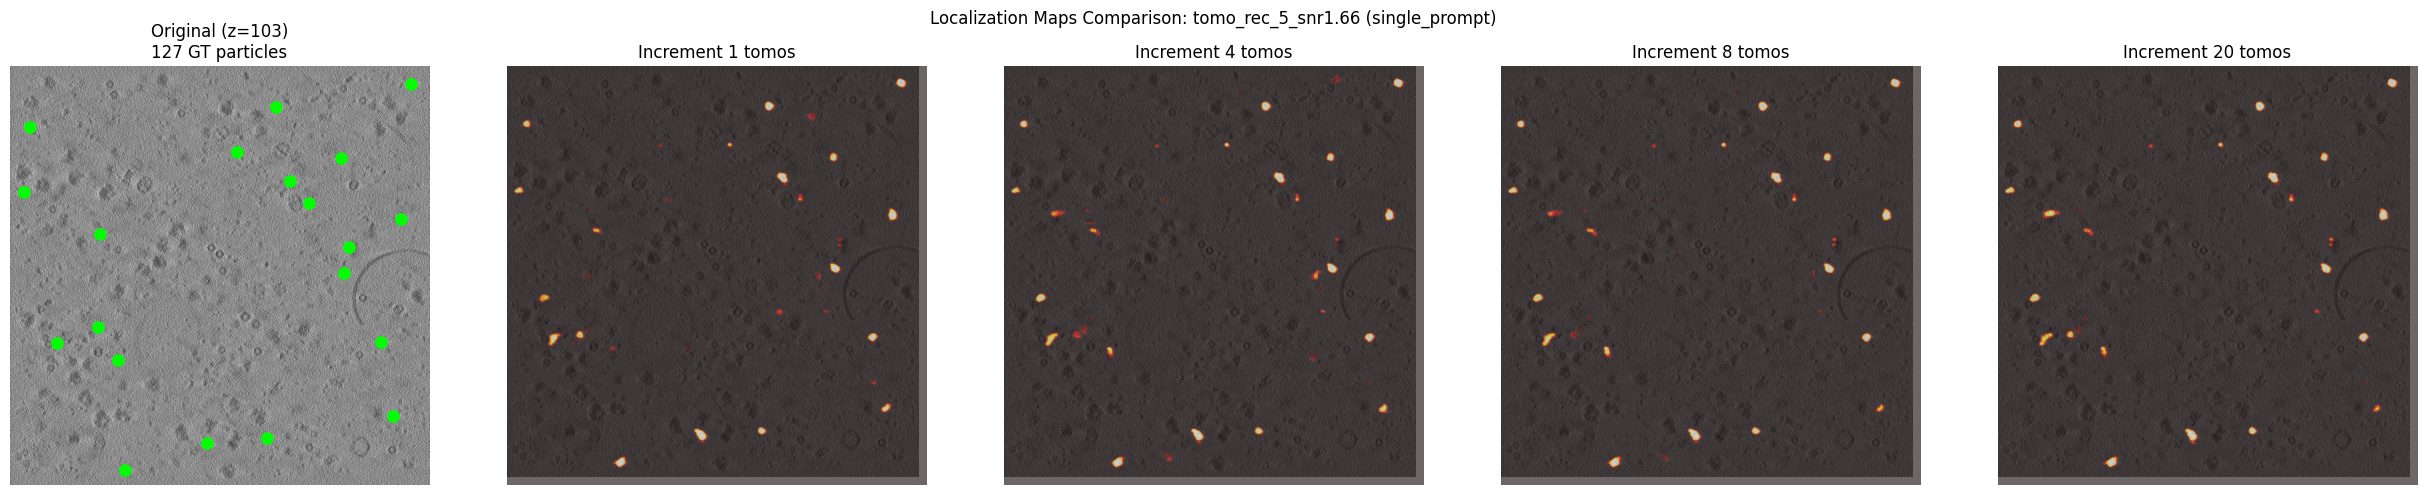


✅ Comparison plot saved


In [17]:
# Visualize localization maps for different increments
def visualize_locmaps_comparison(tomo_name, increments_to_show=[1, 4, 20], prompt_type="single_prompt"):
    """
    Visualize localization maps from different training increments for comparison.
    
    Args:
        tomo_name: Name of the tomogram to visualize
        increments_to_show: List of increments to compare
        prompt_type: 'single_prompt' or 'multi_prompt_n10'
    """
    # Load original tomogram
    tomo_file = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
    if not tomo_file.exists():
        print(f"⚠️ Tomogram not found: {tomo_file}")
        return
    
    tomo = load_mrc_data(str(tomo_file)).numpy()
    
    # Get ground truth
    gt_coords = gt_coords_dict.get(tomo_name, np.array([]).reshape(0, 3))
    
    # Find mid-z slice with particles
    if len(gt_coords) > 0:
        mid_z = int(np.median(gt_coords[:, 2]))
    else:
        mid_z = tomo.shape[0] // 2
    
    n_plots = len(increments_to_show) + 1
    fig, axes = plt.subplots(1, n_plots, figsize=(5*n_plots, 5))
    
    # Original tomogram
    axes[0].imshow(tomo[mid_z], cmap='gray')
    if len(gt_coords) > 0:
        z_mask = np.abs(gt_coords[:, 2] - mid_z) < 10
        axes[0].scatter(gt_coords[z_mask, 0], gt_coords[z_mask, 1], 
                       c='lime', s=50, marker='o', facecolors='none', linewidths=2)
    axes[0].set_title(f'Original (z={mid_z})\n{len(gt_coords)} GT particles')
    axes[0].axis('off')
    
    # Results directory for this prompt type (inside checkpoints/)
    results_base_dir = EXP3_CHECKPOINTS_DIR / f"results_{prompt_type}"
    
    # Localization maps for each increment
    for i, increment in enumerate(increments_to_show):
        ax = axes[i + 1]
        
        # Look in the correct results directory: checkpoints/results_{prompt_type}/increment_{n}/
        locmap_dir = results_base_dir / f"increment_{increment}" / "full_segmentation_output"
        locmap_file = locmap_dir / f"{tomo_name}.pt"
        
        if locmap_file.exists():
            locmap_data = torch.load(locmap_file, weights_only=False)
            
            if isinstance(locmap_data, dict):
                pred_locmap = list(locmap_data.values())[0]
                if hasattr(pred_locmap, 'numpy'):
                    pred_locmap = pred_locmap.numpy()
            elif hasattr(locmap_data, 'numpy'):
                pred_locmap = locmap_data.numpy()
            else:
                pred_locmap = locmap_data
            
            if len(pred_locmap.shape) == 4:
                pred_locmap = pred_locmap[1] if pred_locmap.shape[0] > 1 else pred_locmap[0]
            
            ax.imshow(tomo[mid_z], cmap='gray')
            ax.imshow(pred_locmap[mid_z], cmap='hot', alpha=0.6)
            ax.set_title(f'Increment {increment} tomos')
        else:
            ax.imshow(tomo[mid_z], cmap='gray', alpha=0.3)
            ax.text(0.5, 0.5, f'No data\n{locmap_dir.name}', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=10, color='red')
            ax.set_title(f'Increment {increment} (N/A)')
        
        ax.axis('off')
    
    plt.suptitle(f'Localization Maps Comparison: {tomo_name} ({prompt_type})')
    plt.tight_layout()
    return fig

# Visualize for first validation tomogram
if EXP3_VAL_TOMOS:
    # Check which prompt types have results
    available_prompt_types = [d.name.replace("results_", "") for d in EXP3_CHECKPOINTS_DIR.iterdir() 
                              if d.is_dir() and d.name.startswith("results_")]
    
    prompt_to_use = "single_prompt" if "single_prompt" in available_prompt_types else (
        available_prompt_types[0] if available_prompt_types else "single_prompt"
    )
    
    # Check which increments have results for this prompt type
    results_dir = EXP3_CHECKPOINTS_DIR / f"results_{prompt_to_use}"
    if results_dir.exists():
        available_increments = sorted([int(d.name.split("_")[1]) for d in results_dir.iterdir() 
                                       if d.is_dir() and d.name.startswith("increment_")])
        increments_to_show = [inc for inc in [1, 4, 8, 20] if inc in available_increments]
        if not increments_to_show and available_increments:
            increments_to_show = available_increments[:4]  # Show first 4 available
    else:
        increments_to_show = [1, 4, 8, 20]
    
    print(f"📊 Available prompt types: {available_prompt_types}")
    print(f"📊 Using prompt type: {prompt_to_use}")
    print(f"📊 Increments to show: {increments_to_show}")
    
    fig = visualize_locmaps_comparison(EXP3_VAL_TOMOS[0], increments_to_show=increments_to_show, prompt_type=prompt_to_use)
    if fig:
        plt.savefig(EXP_RESULTS_DIR / f"locmaps_comparison_{EXP3_VAL_TOMOS[0]}.png", 
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f"\n✅ Comparison plot saved")

## Summary and Conclusions

This notebook provides a comprehensive evaluation pipeline for the incremental fine-tuning experiment. Key findings:

In [18]:
if results_df is not None and len(results_df) > 0:
    print("=" * 70)
    print("EXPERIMENT SUMMARY")
    print("=" * 70)
    
    # Find optimal increment
    summary_by_inc = results_df.groupby('increment')['f1'].mean()
    best_increment = summary_by_inc.idxmax()
    best_f1 = summary_by_inc.max()
    
    print(f"\n🏆 Best performing increment: {best_increment} tomograms (F1={best_f1:.3f})")
    
    # Find minimum viable increment (90% of best performance)
    threshold_f1 = 0.9 * best_f1
    viable_increments = summary_by_inc[summary_by_inc >= threshold_f1].index.tolist()
    min_viable = min(viable_increments) if viable_increments else None
    
    if min_viable:
        print(f"📊 Minimum viable increment (≥90% of best): {min_viable} tomograms")
        print(f"   → Data efficiency: achieve {summary_by_inc[min_viable]/best_f1*100:.1f}% of best with {min_viable/best_increment*100:.1f}% of data")
    
    # Performance plateau analysis
    improvements = summary_by_inc.diff()
    plateau_increment = None
    for inc in sorted(summary_by_inc.index)[1:]:
        if improvements[inc] < 0.01:  # Less than 1% improvement
            plateau_increment = inc
            break
    
    if plateau_increment:
        print(f"📈 Performance plateau reached at: {plateau_increment} tomograms")
    
    print(f"\n📋 Full results saved to: {EXP_RESULTS_DIR}")
else:
    print("⚠️ No evaluation results available.")
    print("   Run the fine-tuning and inference scripts first.")

EXPERIMENT SUMMARY

🏆 Best performing increment: 16 tomograms (F1=0.900)
📊 Minimum viable increment (≥90% of best): 4 tomograms
   → Data efficiency: achieve 93.1% of best with 25.0% of data
📈 Performance plateau reached at: 12 tomograms

📋 Full results saved to: /home/carloshg/Dev/cryoet-particle-picking/results/exp3_ppicker_limits


multi_prompt_n10 (top): 12 / F1=0.919 / TP=590, FP=70, FN=32
single_prompt (top): 16 / F1=0.888 / TP=611, FP=190, FN=11

Best precision/F1 with multi_prompt_n10 (better FP) sacrificing recall.

For best data efficiency use multi_prompt_n10 with 4 tomos.

NOTE: tomo 8 downgrade the F1 mean.